In [1]:
import os
import mne
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# dataset_utils specific imports
from typing import Optional, List
from joblib import Parallel, delayed
from tqdm import tqdm 

In [2]:
from dataset_utls import find_edf_files, get_metadata_from_files, compute_metadata_statistics, create_stats_dataframe, compute_channel_stats, plot_channel_frequencies, preprocess_eeg, segment_eeg

In [3]:
DATA_PATH = '/Users/belial/Public/OneDrive - elte.hu/ELTE/Research_Projects/P2-Anomaly_detection/TUH_EEG_Corpus_v2.0.1/'

In [4]:
common_channels = sorted(
    [
        "EEG FP1-LE",
        "EEG FP2-LE",
        "EEG F3-LE",
        "EEG F4-LE",
        "EEG C3-LE",
        "EEG C4-LE",
        "EEG P3-LE",
        "EEG P4-LE",
        "EEG O1-LE",
        "EEG O2-LE",
        "EEG F7-LE",
        "EEG F8-LE",
        "EEG T3-LE",
        "EEG T4-LE",
        "EEG T5-LE",
        "EEG T6-LE",
        "EEG FZ-LE",
        "EEG CZ-LE",
        "EEG PZ-LE",
    ]
)
print(type(common_channels), len(common_channels))

<class 'list'> 19


In [5]:
# extract metadata from the files
edf_files_normal, _, _ = find_edf_files(DATA_PATH, montage='_le', epilepsy=False)
edf_files_abnormal, _, _ = find_edf_files(DATA_PATH, montage='_le', epilepsy=True)
normal_metadata_list = get_metadata_from_files(edf_files_normal)
abnormal_metadata_list = get_metadata_from_files(edf_files_abnormal)

In [6]:
from joblib import Parallel, delayed
from tqdm import tqdm  # For progress bars

def preprocess_bulk(
    file_paths: List[str],
    selected_channels: Optional[List[str]] = None,
    n_jobs: int = -1  # Use all CPU cores
) -> List[Optional[np.ndarray]]:
    return Parallel(n_jobs=n_jobs)(
        delayed(preprocess_eeg)(fp, selected_channels)
        for fp in tqdm(file_paths, desc="Processing files")
    )

In [7]:
normal_preprocessed_data = preprocess_bulk(edf_files_normal, selected_channels=common_channels, n_jobs=4)
abnormal_preprocessed_data = preprocess_bulk(edf_files_abnormal, selected_channels=common_channels, n_jobs=4)

Processing files: 100%|██████████| 106/106 [01:08<00:00,  1.56it/s]


In [8]:
print(type(normal_preprocessed_data), len(normal_preprocessed_data))
print(type(abnormal_preprocessed_data), len(abnormal_preprocessed_data))
# Check the first preprocessed data
print(type(normal_preprocessed_data[0]), normal_preprocessed_data[0].shape)
# Check the first preprocessed data
print(type(abnormal_preprocessed_data[0]), abnormal_preprocessed_data[0].shape)

<class 'list'> 41
<class 'list'> 106
<class 'numpy.ndarray'> (19, 345750)
<class 'numpy.ndarray'> (19, 278000)


In [9]:
data_epochs = np.empty((0, len(common_channels), int(250)))
for i, data in enumerate(normal_preprocessed_data):
    segments = segment_eeg(data, sfreq=250, window_sec=1, overlap=0.5)
    data_epochs = np.vstack((data_epochs, segments))
print(f"All data shape: {data_epochs.shape}")

All data shape: (76207, 19, 250)


In [ ]:
data_epochs = np.empty((0, len(common_channels), int(250)))
for i, data in enumerate(abnormal_preprocessed_data):
    segments = segment_eeg(data, sfreq=250, window_sec=1, overlap=0.5)
    data_epochs = np.vstack((data_epochs, segments))
print(f"All data shape: {data_epochs.shape}")

# Loading Raw Data

In [54]:
normal_sub =  mne.io.read_raw_edf(edf_files_normal[0], preload=True)
abnormal_sub =  mne.io.read_raw_edf(edf_files_abnormal[0], preload=True)

Extracting EDF parameters from /Users/belial/Public/OneDrive - elte.hu/ELTE/Research_Projects/P2-Anomaly_detection/TUH_EEG_Corpus_v2.0.1/01_no_epilepsy/aaaaamba/s001_2011/02_tcp_le/aaaaamba_s001_t000.edf...


EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 345749  =      0.000 ...  1382.996 secs...
Extracting EDF parameters from /Users/belial/Public/OneDrive - elte.hu/ELTE/Research_Projects/P2-Anomaly_detection/TUH_EEG_Corpus_v2.0.1/00_epilepsy/aaaaabju/s001_2003/02_tcp_le/aaaaabju_s001_t000.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 277999  =      0.000 ...  1111.996 secs...


In [89]:
selected_channels = common_channels
no_raw = normal_sub.copy()
if selected_channels:
        available_chs = no_raw.ch_names
        missing_chs = [ch for ch in selected_channels if ch not in available_chs]
        no_raw.pick(selected_channels)

In [90]:
ab_raw = abnormal_sub.copy()
if selected_channels:
        available_chs = ab_raw.ch_names
        missing_chs = [ch for ch in selected_channels if ch not in available_chs]
        ab_raw.pick(selected_channels)

# Get Info and crop the first minute

In [91]:
no_raw.info

Measurement date,"January 01, 2011 00:00:00 GMT"
Experimenter,Unknown
Participant,aaaaamba
Digitized points,Not available
Good channels,19 EEG
Bad channels,None
EOG channels,Not available
ECG channels,Not available
Sampling frequency,250.00 Hz
Highpass,0.00 Hz
Lowpass,125.00 Hz


In [92]:
ab_raw.info

Measurement date,"January 01, 2003 00:00:00 GMT"
Experimenter,Unknown
Participant,aaaaabju
Digitized points,Not available
Good channels,19 EEG
Bad channels,None
EOG channels,Not available
ECG channels,Not available
Sampling frequency,250.00 Hz
Highpass,0.00 Hz
Lowpass,125.00 Hz


In [120]:
tmin = 0
tmax = 2
no_cropped = no_raw.copy()
no_cropped.crop(tmin, tmax)
ab_cropped = ab_raw.copy()
ab_cropped.crop(tmin, tmax)


Measurement date,"January 01, 2003 00:00:00 GMT"
Experimenter,Unknown
Participant,aaaaabju
Digitized points,Not available
Good channels,19 EEG
Bad channels,None
EOG channels,Not available
ECG channels,Not available
Sampling frequency,250.00 Hz
Highpass,0.00 Hz
Lowpass,125.00 Hz


Effective window size : 8.192 (s)


/var/folders/gn/g0szlcgn2sq2ycrwdq8bmf5w0000gn/T/ipykernel_24614/3832758911.py:1: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  ab_raw.compute_psd().plot()
/Users/belial/.pyenv/versions/3.8.20/lib/python3.8/site-packages/mne/viz/utils.py:165: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  (fig or plt).show(**kwargs)


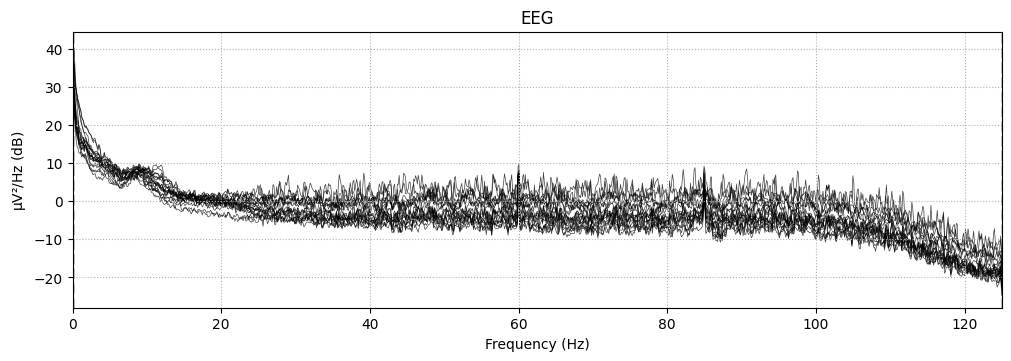

In [112]:
ab_raw.compute_psd().plot()


Effective window size : 8.192 (s)


/var/folders/gn/g0szlcgn2sq2ycrwdq8bmf5w0000gn/T/ipykernel_24614/815673437.py:1: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  no_raw.compute_psd().plot()
/Users/belial/.pyenv/versions/3.8.20/lib/python3.8/site-packages/mne/viz/utils.py:165: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  (fig or plt).show(**kwargs)


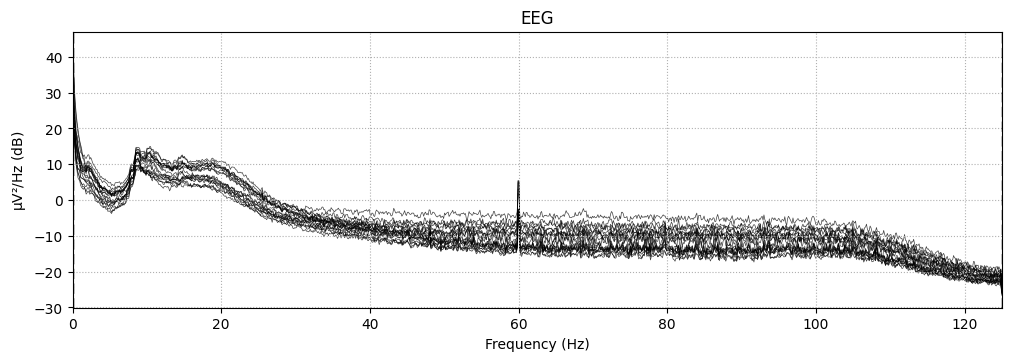

In [113]:
no_raw.compute_psd().plot()


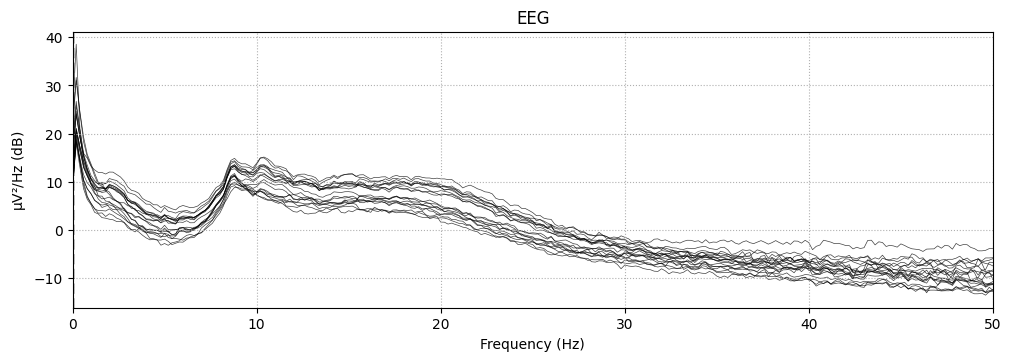

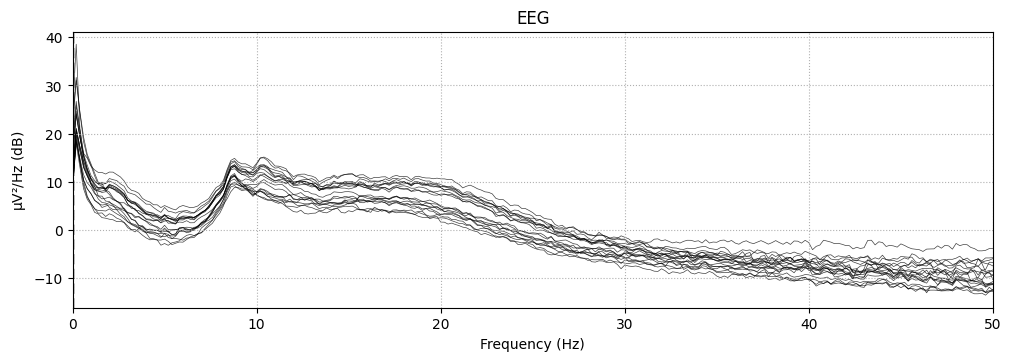

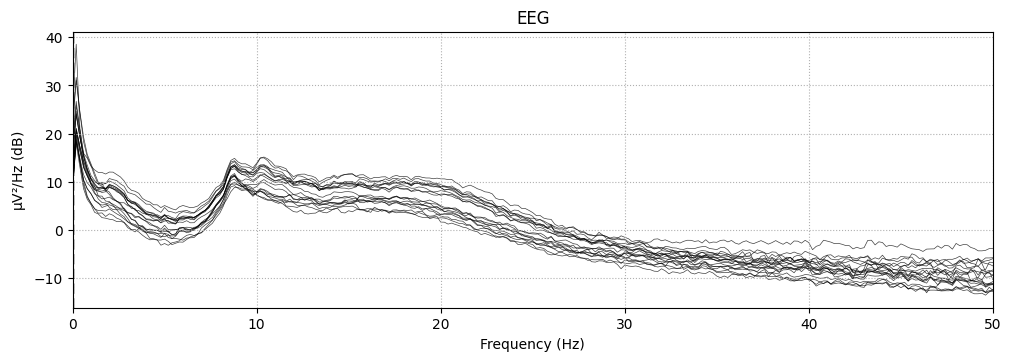

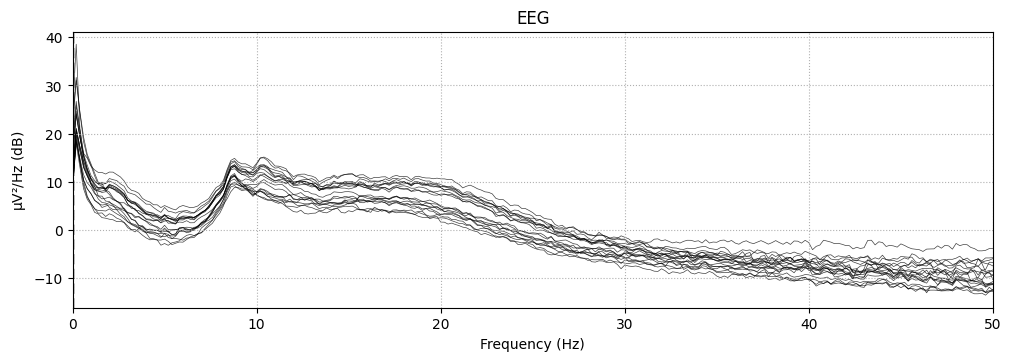

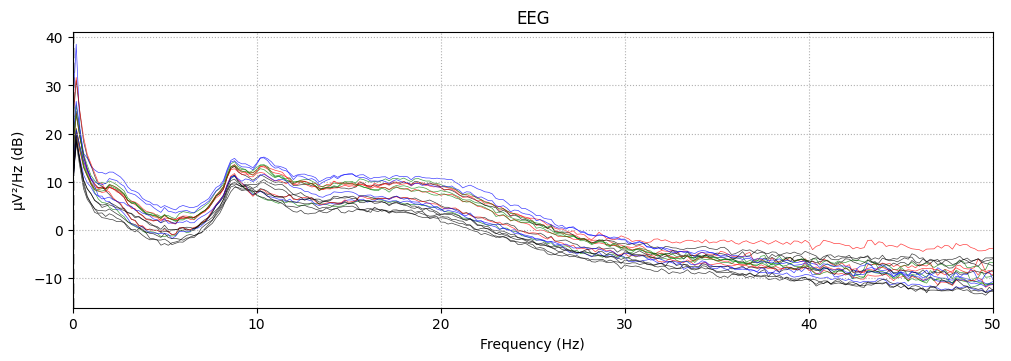

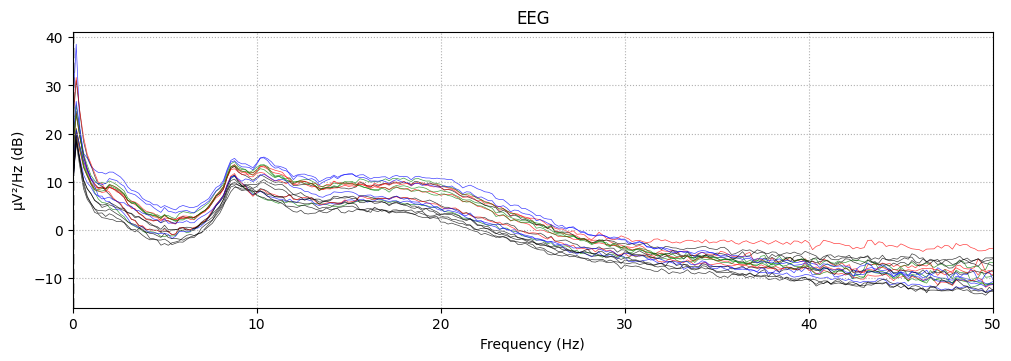

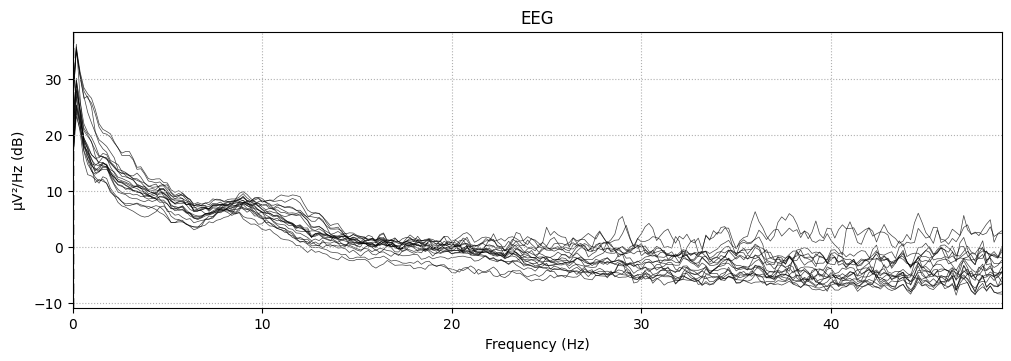

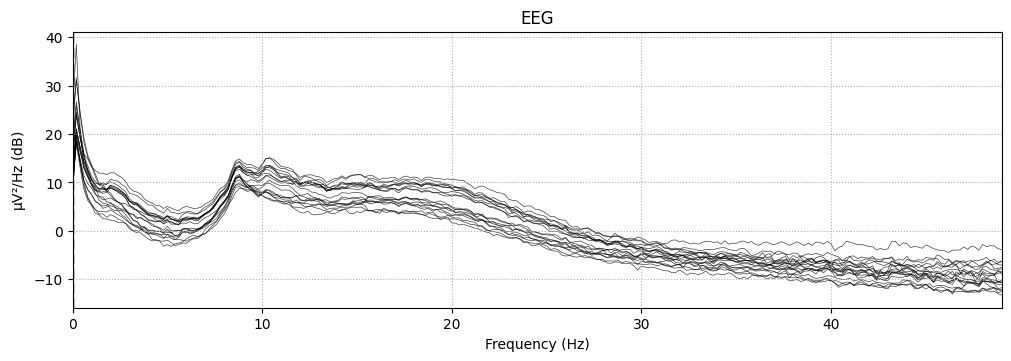

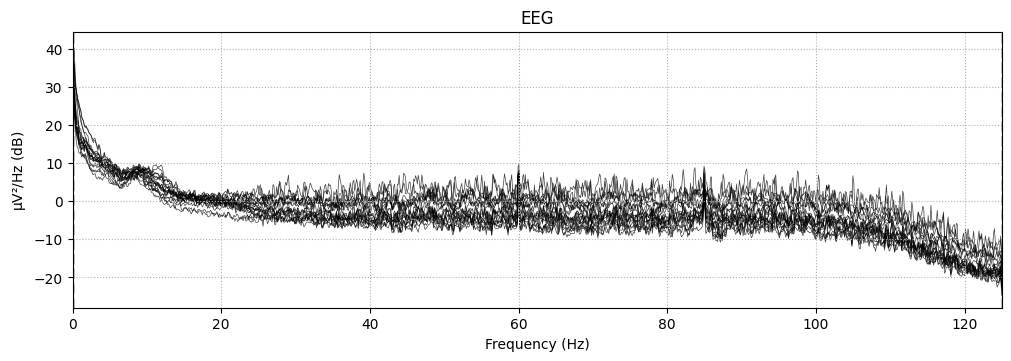

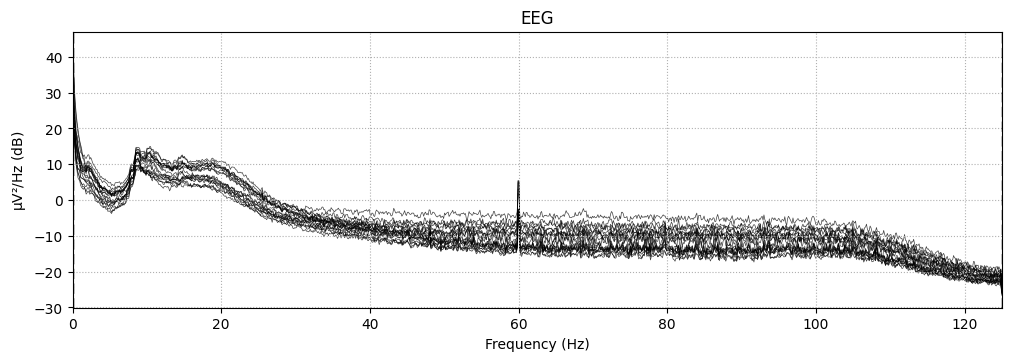

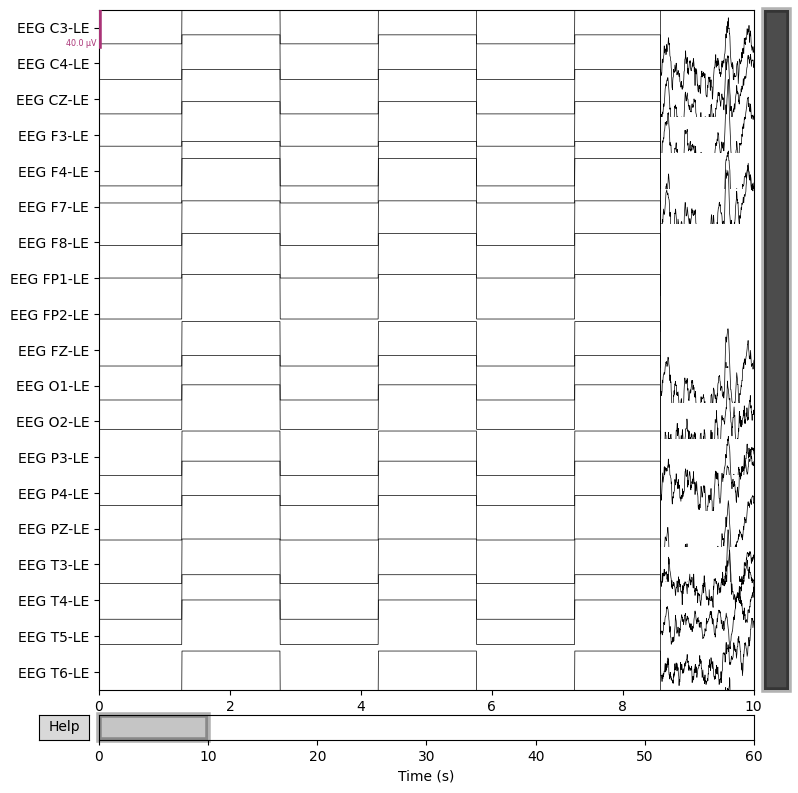

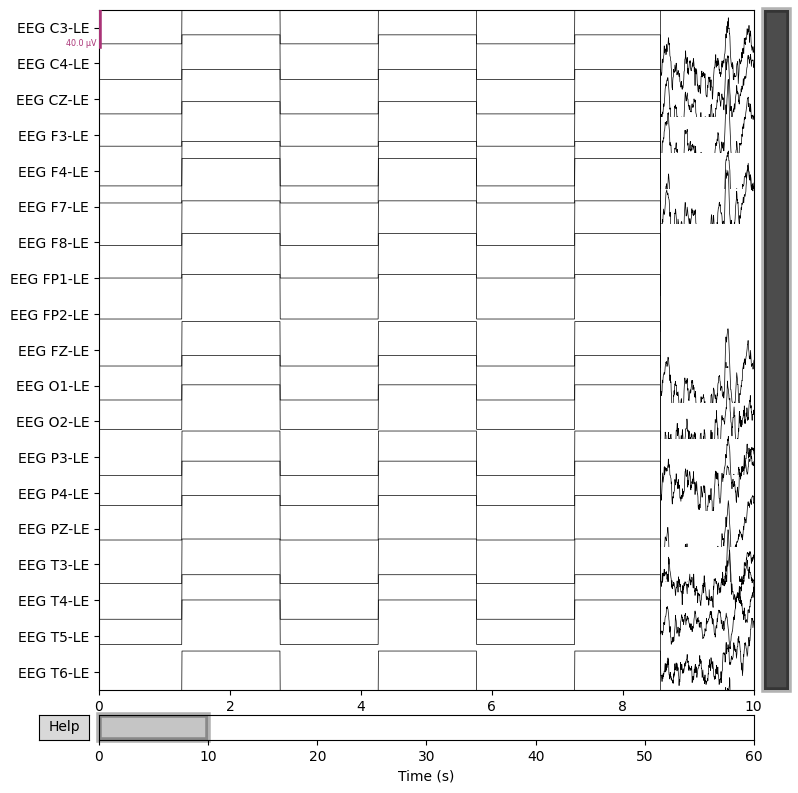

In [114]:
ab_cropped.plot()

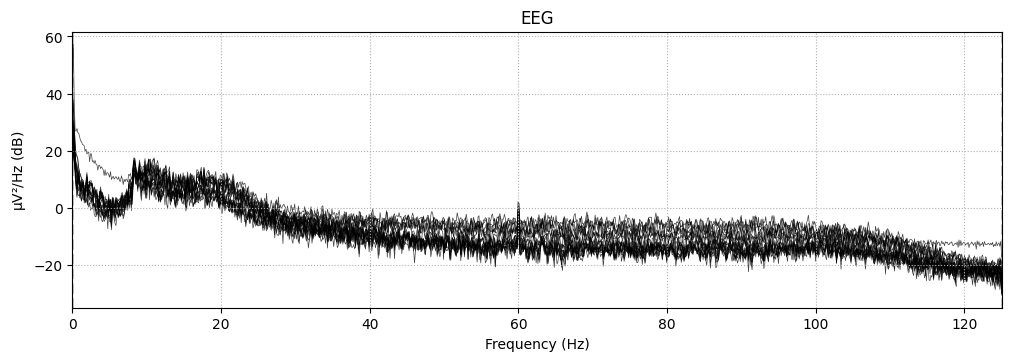

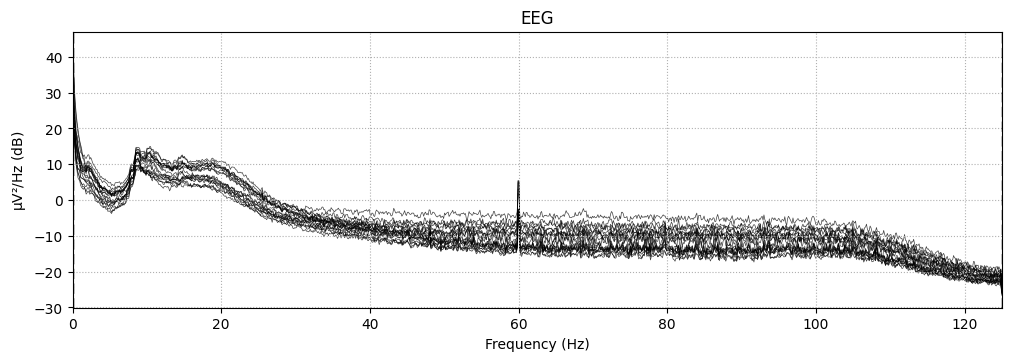

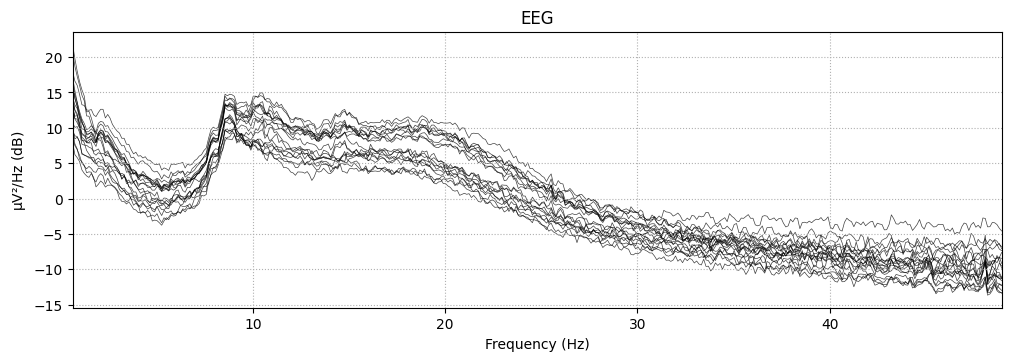

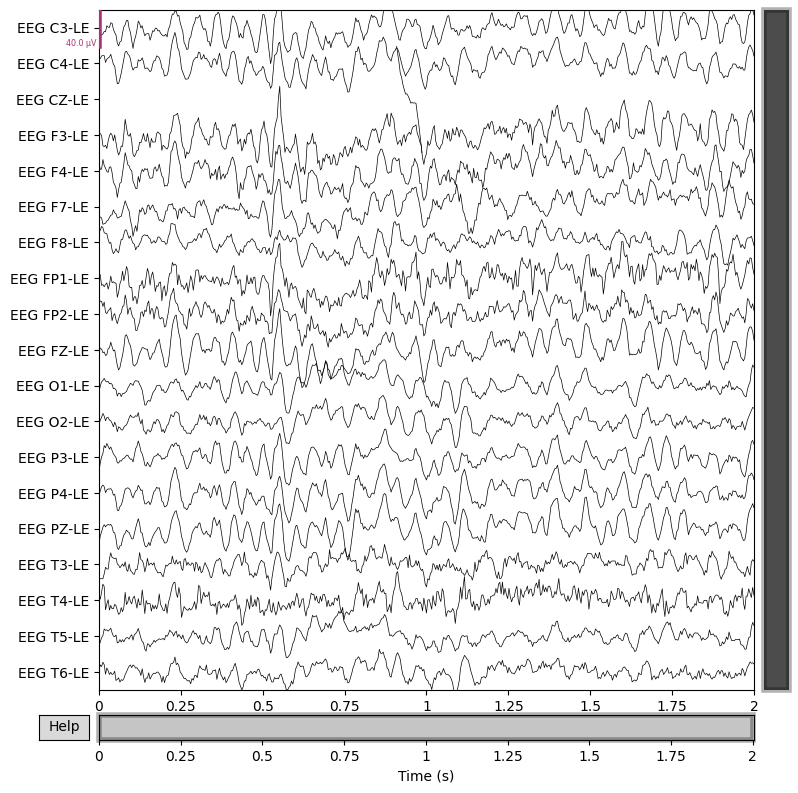

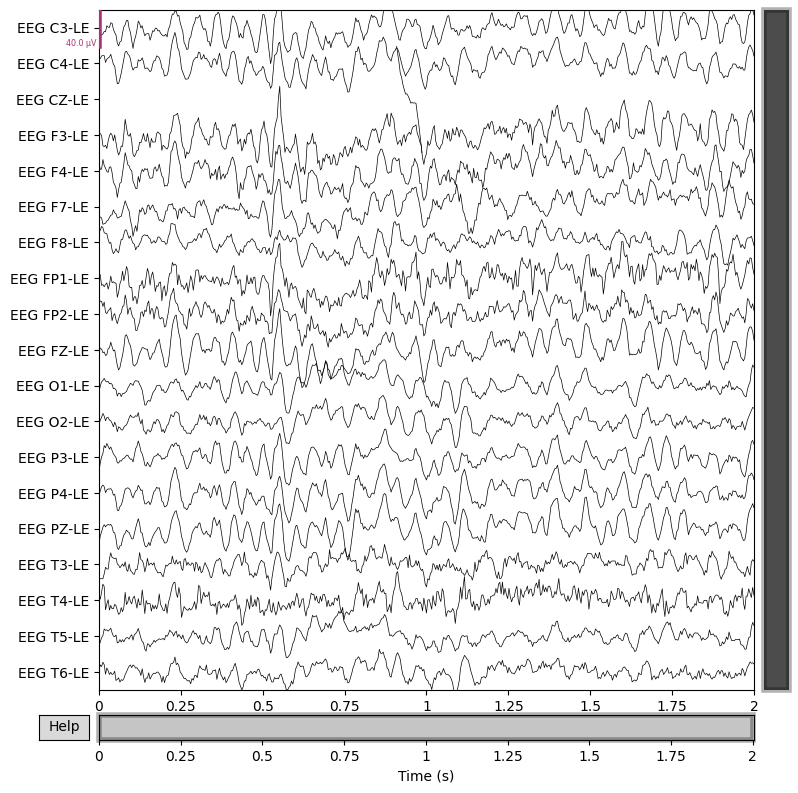

In [121]:
no_cropped.plot()

Effective window size : 8.192 (s)


/var/folders/gn/g0szlcgn2sq2ycrwdq8bmf5w0000gn/T/ipykernel_24614/4057628014.py:1: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  no_raw.compute_psd(fmin=0.5, fmax=49).plot()
/Users/belial/.pyenv/versions/3.8.20/lib/python3.8/site-packages/mne/viz/utils.py:165: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  (fig or plt).show(**kwargs)


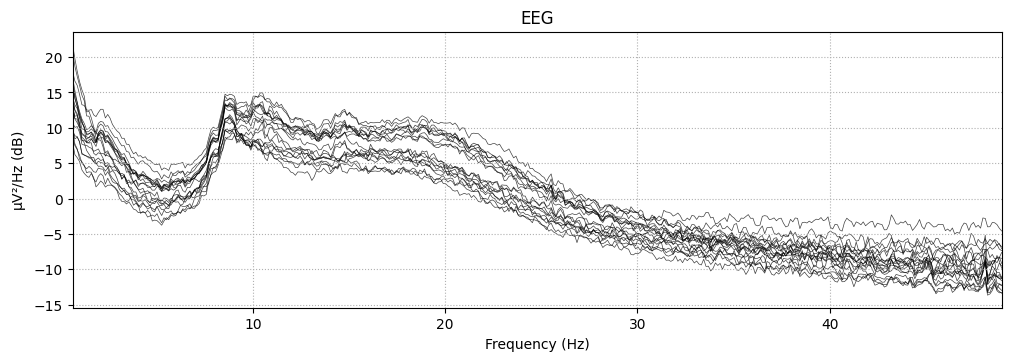

In [119]:
no_raw.compute_psd(fmin=0.5, fmax=49).plot()

Effective window size : 2.004 (s)


/var/folders/gn/g0szlcgn2sq2ycrwdq8bmf5w0000gn/T/ipykernel_24614/4176517785.py:1: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  no_cropped.compute_psd(fmin=0.5, fmax=49).plot()
/Users/belial/.pyenv/versions/3.8.20/lib/python3.8/site-packages/mne/viz/utils.py:165: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  (fig or plt).show(**kwargs)


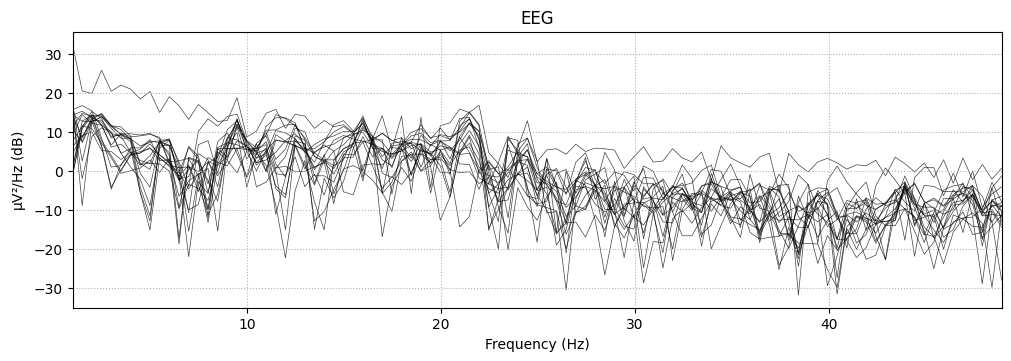

In [122]:
no_cropped.compute_psd(fmin=0.5, fmax=49).plot()

Effective window size : 8.192 (s)


/var/folders/gn/g0szlcgn2sq2ycrwdq8bmf5w0000gn/T/ipykernel_24614/4212396183.py:1: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  no_raw.compute_psd().plot()
/Users/belial/.pyenv/versions/3.8.20/lib/python3.8/site-packages/mne/viz/utils.py:165: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  (fig or plt).show(**kwargs)


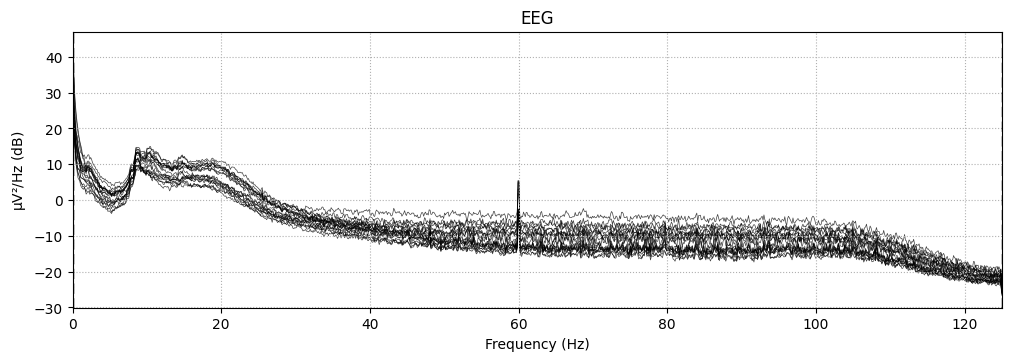

In [123]:
no_raw.compute_psd().plot()

Effective window size : 8.192 (s)


/var/folders/gn/g0szlcgn2sq2ycrwdq8bmf5w0000gn/T/ipykernel_24614/4057628014.py:1: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  no_raw.compute_psd(fmin=0.5, fmax=49).plot()
/Users/belial/.pyenv/versions/3.8.20/lib/python3.8/site-packages/mne/viz/utils.py:165: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  (fig or plt).show(**kwargs)


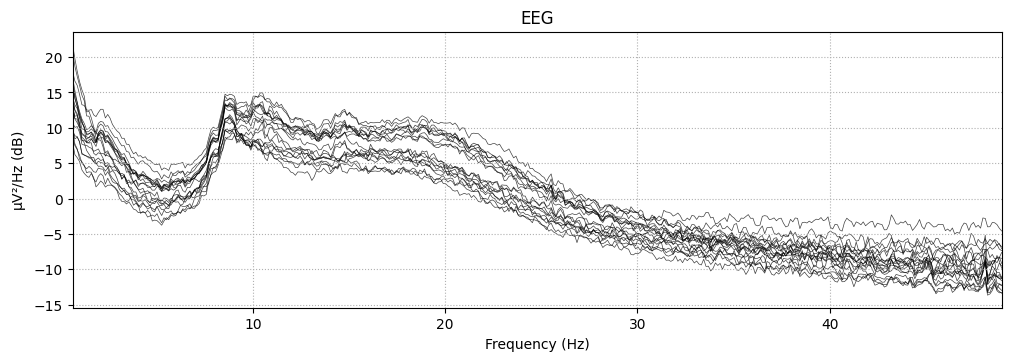

In [125]:
no_raw.compute_psd(fmin=0.5, fmax=49).plot()

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 49 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 49.00 Hz
- Upper transition bandwidth: 12.25 Hz (-6 dB cutoff frequency: 55.12 Hz)
- Filter length: 1651 samples (6.604 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    1.1s


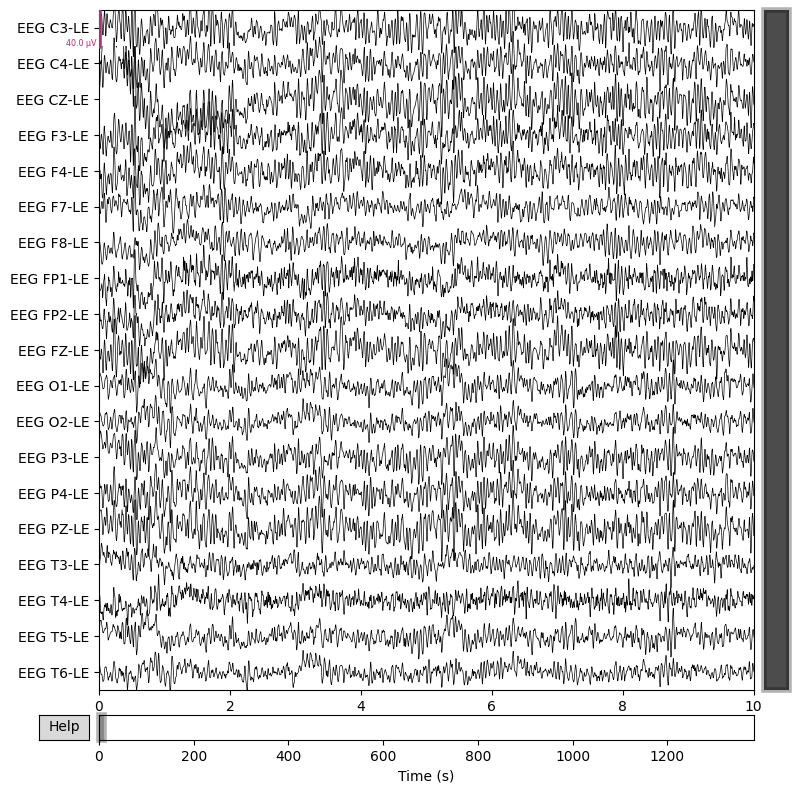

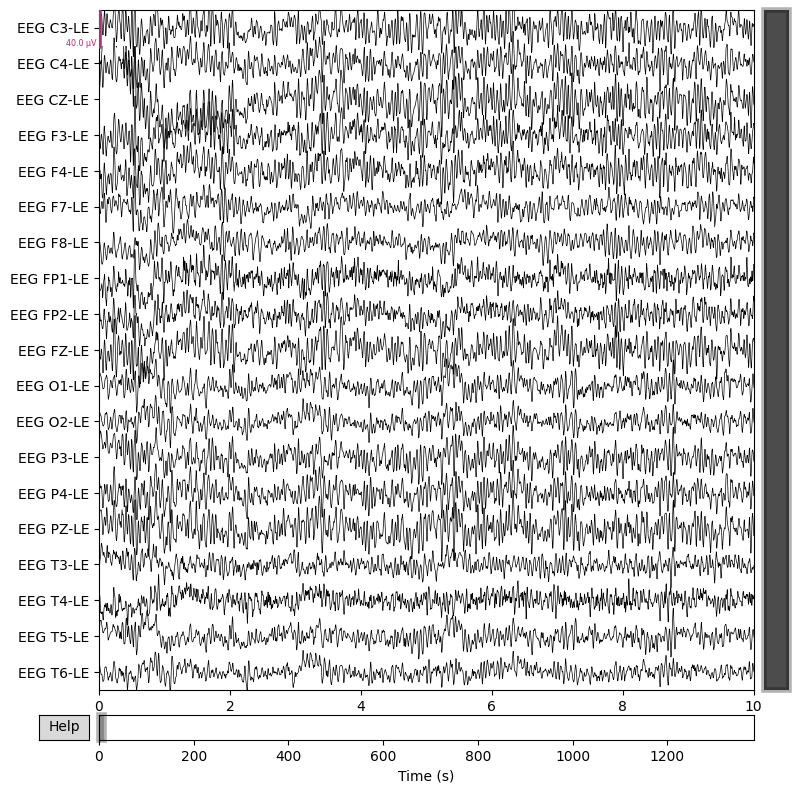

In [128]:
no_raw.filter(0.5, 49, fir_design='firwin').plot()